In [1]:
import numpy as np
from datascience import *

import matplotlib.pyplot as plt

%matplotlib inline

/Users/ayushthasale07/Sarg<3/Data8/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


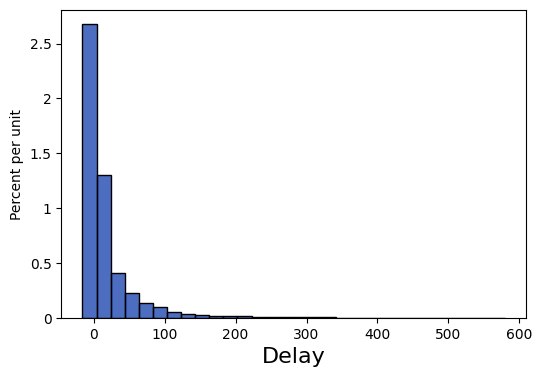

In [4]:
united = Table.read_table("united.csv")
united.hist("Delay", bins=30)

In [5]:
def one_sample_mean(s):
    sampled_flights = united.sample(s)
    return np.mean(sampled_flights.column("Delay"))

In [6]:
def ten_thousand_sample_means(s):
    means = make_array()
    for _ in range(10_000):
        means = np.append(means, one_sample_mean(s))

    return means

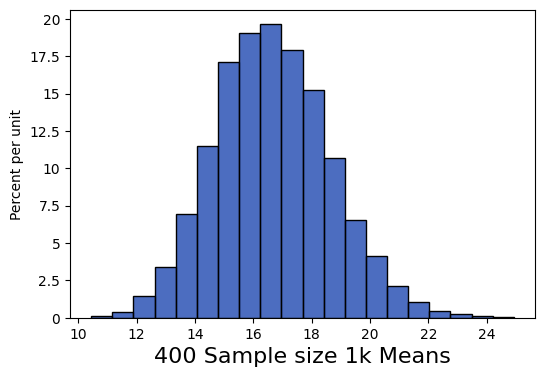

In [8]:
sample_means_400 = ten_thousand_sample_means(400)

Table().with_column("400 Sample size 1k Means", sample_means_400).hist(bins=20)

Population Average:  16.6581555154


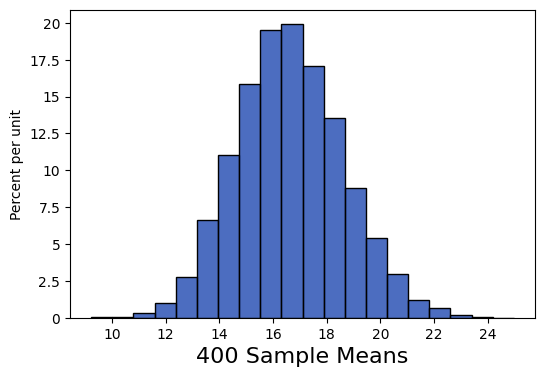

In [10]:
#  CLT Center
delay_mean = np.mean(united.column("Delay"))
sample_means_400 = ten_thousand_sample_means(400)
Table().with_column("400 Sample Means", sample_means_400).hist(bins=20)
print("Population Average: ", delay_mean)

In [12]:
# CLT Spread
sample_means_900 = ten_thousand_sample_means(900)
means_tbl = Table().with_columns(
    "400", sample_means_400,
    "900", sample_means_900
)

Text(0.5, 1.0, 'Distribution of Sample Average')

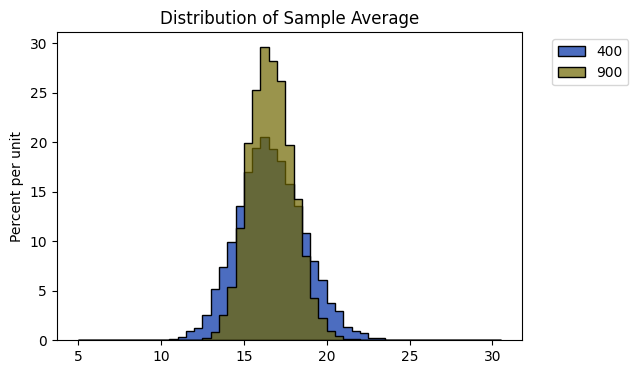

In [13]:
means_tbl.hist(bins=np.arange(5, 31, 0.5))
plt.title("Distribution of Sample Average")

In [18]:
"""Empirical distribution of random sample means"""
delay_sd = np.std(united.column("Delay"))

def plot_and_summarize_sample_means(sample_size):
    sample_means = ten_thousand_sample_means(sample_size)
    sample_means_tbl = Table().with_column('Sample Means', sample_means)
    
    # Print some information about the distribution of the sample means
    print("Sample size: ", sample_size)
    print("Population mean:", delay_mean)
    print("Average of sample means: ", np.mean(sample_means))
    print("\nPopulation SD:", delay_sd)
    print("SD of sample means:", np.std(sample_means))
    print("Ratio:", delay_sd / np.std(sample_means))

    # Plot a histogram of the sample means
    sample_means_tbl.hist(bins=20)
    plt.xlabel('Sample Means')
    plt.title('Sample Size ' + str(sample_size))

Sample size:  100
Population mean: 16.6581555154
Average of sample means:  16.593903

Population SD: 39.4801998516
SD of sample means: 3.98828886323
Ratio: 9.89903219287


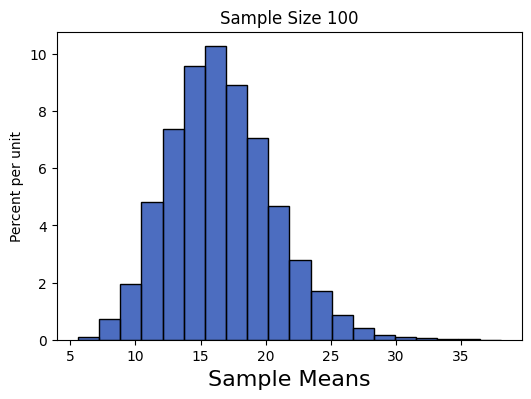

In [19]:
plot_and_summarize_sample_means(100)

Sample size:  400
Population mean: 16.6581555154
Average of sample means:  16.6663895

Population SD: 39.4801998516
SD of sample means: 1.96853770012
Ratio: 20.0555975378


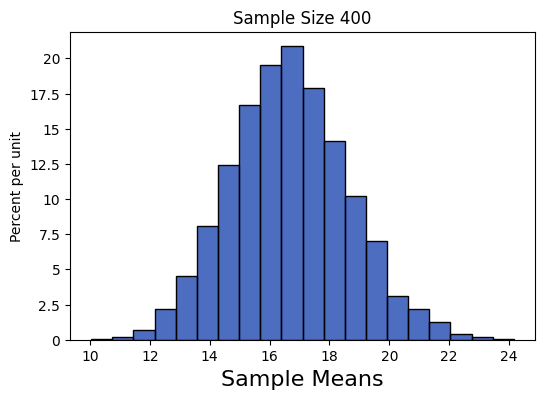

In [20]:
plot_and_summarize_sample_means(400)

Sample size:  900
Population mean: 16.6581555154
Average of sample means:  16.6575836667

Population SD: 39.4801998516
SD of sample means: 1.31718333003
Ratio: 29.9732003522


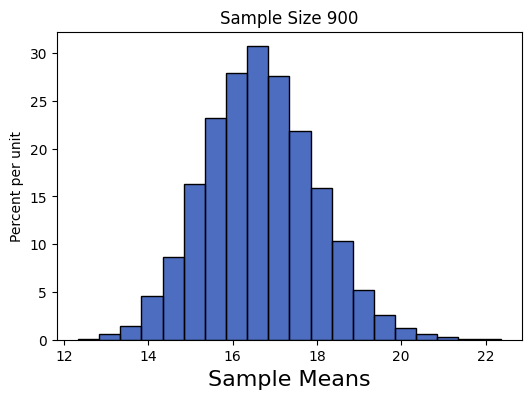

In [21]:
plot_and_summarize_sample_means(900)

Sample size:  1600
Population mean: 16.6581555154
Average of sample means:  16.6659903125

Population SD: 39.4801998516
SD of sample means: 0.984620883945
Ratio: 40.0968540231


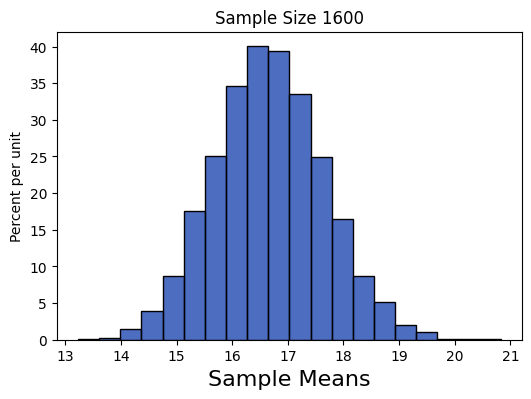

In [22]:
plot_and_summarize_sample_means(1600)